# Workflow 8: Iterative | Social Media Post generator
Author: Nihit Kumar 

---

**Task**: When any input is provided by the user, LLM (Generator) will create a social media (Twitter/X) post on that topic. Once created, another LLM (Evaluator) will evaluate the quality of the post. If the quality is not good, another LLM (Optimizer) will optimize the post.  
This loop will go on unless the final post is apporved, thereby uploading the post.   

**States**: 
- `topic` *str* : user input - Provide topic for tweet
- `tweet` *str* : LLM Generated - LLM1 Generates Tweet
- `evaluation` Literal (*Approved* or *Needs Improvement*) : LLM Generated - LLM2 approves or rejected the tweet. If rejected, it does to LLM3 for optimization.
- `feedback` *str* : LLM Generated - Improvement feedbaack from LLM2
- `loop` *int* : user_input/counter - Increase counter everytime LLM2 is called
- `max_loops` *int* : user_input - Max numbers of before, the Tweet will be posted 
- `tweet_history` *List[str]*: operator - History of all the tweets generated
- `feedback_history` *List[str]* : operator - History all the feedbacks provided by the LLM2



In [89]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import SystemMessage, AIMessage, HumanMessage
from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel, Field
from dotenv import load_dotenv
import operator

load_dotenv()

True

In [90]:
##### Temp fix just in case the dotenv is not loading the OpenAI api key
##### Convert this into code cell and execute this cell

#import os  
#import certifi  
#os.environ['SSL_CERT_FILE'] = certifi.where()

In [91]:
# Creating 3 different LLMs for 3 different tasks
# NOTE: LLMs should be selected based on which model is best in the market presently for each task

generator_llm = ChatOpenAI(model='gpt-4o') # Creating Post
evaluator_llm = ChatOpenAI(model='gpt-4o-mini') # Evaluating Post
optimizer_llm = ChatOpenAI(model='gpt-5-nano') # Optimizing the post

In [92]:
# Define State
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal["Approved", "Needs improvement"]
    feedback: str
    loop: int # Count number of loops
    max_loops: int # If evaluator is rejecting the tweet everytime
    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [93]:
def tweet_generator(state: TweetState):

    # Defining prompt/messages to generate the tweet
    messages = [
    SystemMessage(content="You are a funny and clever Twitter/X influencer."),
    HumanMessage(content=f"""
    Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

    Rules:
    - Do NOT use question-answer format.
    - Max 280 characters.
    - Use observational humor, irony, sarcasm, or cultural references.
    - Think in meme logic, punchlines, or relatable takes.
    - Use simple, day to day english
    """)]

    # Invoke the Generator LLM
    response = generator_llm.invoke(messages).content

    return {'tweet': response, 'tweet_history': [response]}

In [94]:
# Creating schema for Evaluator LLM to get desired output
class EvaluationSchema(BaseModel):
    approved : Literal['Approved','Needs improvement'] = Field(...,description='Final evaluation if the tweet can be approved for posting or not')
    feedback: str = Field(description='Feedback on what improvement is required in the tweet')

# updating the Evaluator to provide structured output
evaluator_llm_SO = evaluator_llm.with_structured_output(EvaluationSchema)

In [95]:
def tweet_evaluator(state: TweetState):
    # Define prompt/Message for Evaluator
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
    Evaluate the following tweet:

    Tweet: "{state['tweet' ]}"

    Use the criteria below to evaluate the tweet:

    1. Originality - Is this fresh, or have you seen it a hundred times before?
    2. Humor - Did it genuinely make you smile, laugh, or chuckle?
    3. Punchiness - Is it short, sharp, and scroll-stopping?
    4. Virality Potential - Would people retweet or share it?
    5. Format - Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

    Auto-reject if:
    It's written in question-answer format (e.g., "Why did ... " or "What happens when ... ")
    It exceeds 280 characters
    It reads like a traditional setup-punchline joke
    Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., "Masterpieces of the auntie-uncle
    universe" or vague summaries)

    ### Respond ONLY in structured format:
    evaluation: "approved" or "needs_improvement"
    - feedback: One paragraph explaining the strengths and weaknesses
""")]

    # Invoking the Evaluator LLM with structured output
    response = evaluator_llm_SO.invoke(messages)

    return {'evaluation': response.approved, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [96]:
def tweet_optimizer(state: TweetState):
    # Defining Prompt/Messages for LLM
    messages = [
    SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
    HumanMessage(content=f"""
    Improve the tweet based on this feedback:
    "{state['feedback']}"

    Topic: "{state['topic']}"
    Original Tweet:
    {state['tweet']}

    Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
    """)]

    result = optimizer_llm.invoke(messages).content
    loop = state['loop'] + 1
    
    return {'tweet': result, 'loop': loop, 'tweet_history': [result]}

In [97]:
def approval_checker(state: TweetState):

    if state['evaluation'] == 'Approved' or state['loop'] >= state['max_loops']:
        return 'post_tweet'
    else:
        return 'optimize'

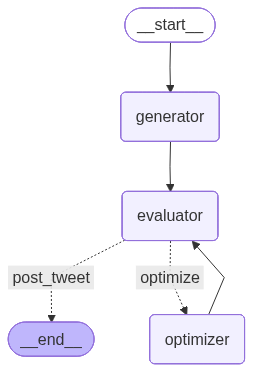

In [98]:
graph = StateGraph(TweetState)

graph.add_node('generator', tweet_generator)
graph.add_node('evaluator', tweet_evaluator)
graph.add_node('optimizer', tweet_optimizer)

graph.add_edge(START, 'generator')
graph.add_edge('generator', 'evaluator')
graph.add_conditional_edges(
    'evaluator',
    approval_checker,
    {
        'post_tweet': END,
        'optimize': 'optimizer'
    }
    )
graph.add_edge('optimizer', 'evaluator')

workflow = graph.compile()
workflow

In [99]:
initial_state = {
    'topic': 'Pandas',
    'loop': 1,
    'max_loops': 5
}

In [100]:
final_state = workflow.invoke(initial_state)

In [101]:
final_state

{'topic': 'Pandas',
 'tweet': 'Pandas redefine wild nights: bamboo couture, nap marathons, and a grin that says I woke up like this. Zero hangovers, 100% cuteness. 🍃🐼',
 'evaluation': 'Approved',
 'feedback': "This tweet showcases originality through its playful take on pandas, offering a fresh perspective with humorous phrases like 'bamboo couture' and 'nap marathons.' The use of emojis adds a fun touch, enhancing its appeal. It’s concise enough to capture attention while being easily shareable, increasing its virality potential. Overall, it combines a relatable theme with clever wordplay, hitting all the right notes for an engaging tweet.",
 'loop': 3,
 'max_loops': 5,
 'tweet_history': ["Pandas are the only animals who look like they just had a rough night out and are still cuter than anyone else's Sunday brunch selfies. Eating bamboo in bed is the ultimate lazy day goals 🍃🐼 #PandaLife",
  'Pandas: the only "wild night" survivors who still pull off bamboo-and-bed chic. Hangover? mor